Генерация иконки кошки на весах для ветеринарного корма...


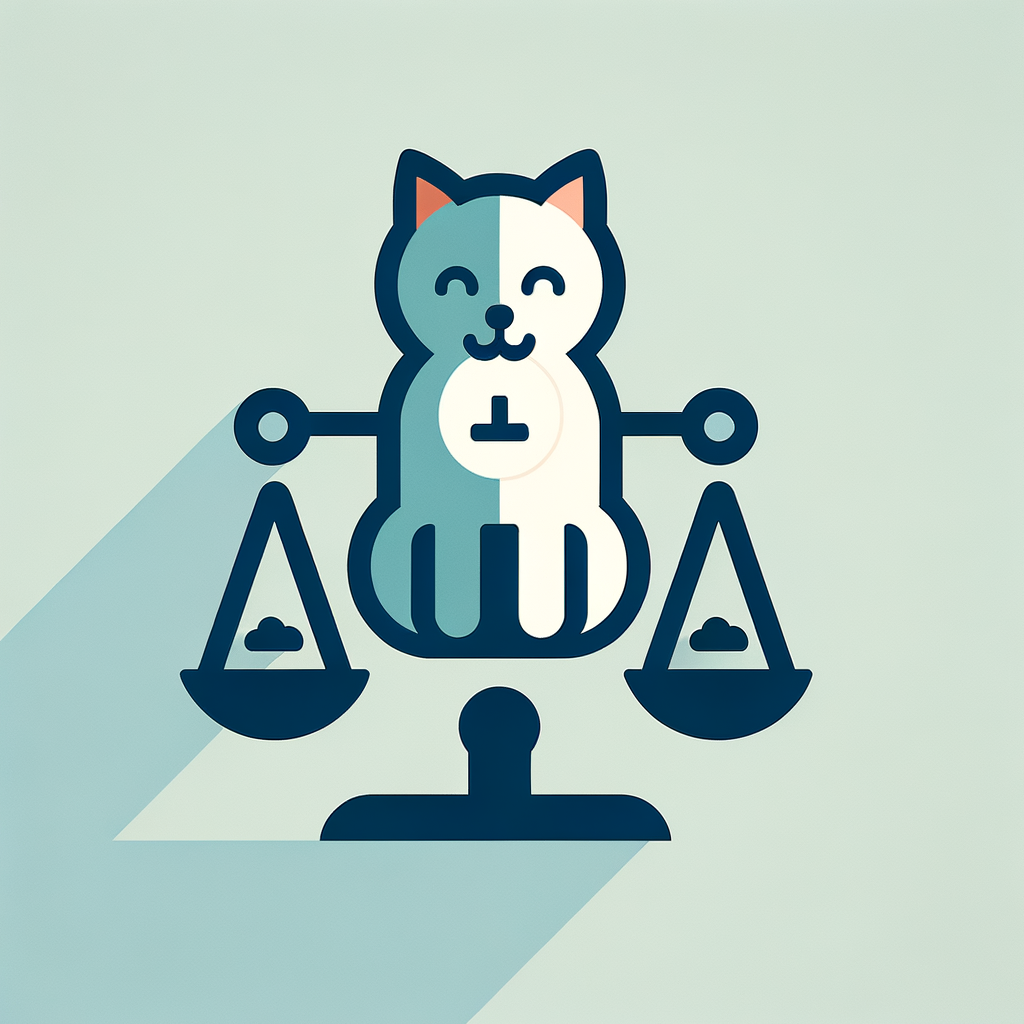

Изображение сохранено локально: cat_balance_food_20250226154152_bbcc18f5.png
Файл успешно загружен в S3: cat_balance_food_20250226154152_bbcc18f5.png
Публичная ссылка: https://c5ed3ec28edd-for-designer.s3.ru1.storage.beget.cloud/cat_balance_food_20250226154152_bbcc18f5.png

Публичные ссылки на сгенерированные изображения:
https://c5ed3ec28edd-for-designer.s3.ru1.storage.beget.cloud/cat_balance_food_20250226154152_bbcc18f5.png


'\nsecond_prompt = cat_food_prompt.replace("navy blue, mint green, and light gray", "orange, teal, and cream")\nprint("\nГенерация альтернативного варианта иконки...")\nsecond_urls = generate_icon(\n    prompt=second_prompt,\n    quality="hd",\n    style="vivid"\n)\n\nif second_urls:\n    s3_urls_alt = download_and_upload_images(second_urls, "cat_balance_food_alt")\n    \n    if s3_urls_alt:\n        print("\nПубличные ссылки на альтернативные изображения:")\n        for url in s3_urls_alt:\n            print(url)\n'

In [11]:
# Генерация иконки кошки на весах для ветеринарного корма с загрузкой в S3 Beget
!pip install openai python-dotenv requests boto3 --quiet

import os
import openai
import requests
import boto3
from botocore.client import Config
from IPython.display import Image, display
from google.colab import userdata
import uuid
from datetime import datetime
import io


In [ ]:

# Конфигурация OpenAI API
openai.api_key = userdata.get('OPENAI_API_KEY')

# Конфигурация S3 хранилища Beget
S3_ENDPOINT = userdata.get('S3_ENDPOINT')
S3_BUCKET = 'c5ed3ec28edd-for-designer'
S3_ACCESS_KEY = userdata.get('S3_ACCESS_KEY')
S3_SECRET_KEY = userdata.get('S3_SECRET_KEY')
S3_PUBLIC_URL_BASE = f'https://{S3_BUCKET}.s3.ru1.storage.beget.cloud'

def generate_icon(prompt, size="1024x1024", quality="hd", style="vivid"):
    """
    Генерирует иконку через DALL-E 3 API

    Параметры:
    prompt (str): Текстовое описание иконки на английском языке
    size (str): Разрешение (1024x1024, 1024x1792 или 1792x1024)
    quality (str): Качество изображения (standard/hd)
    style (str): Стиль генерации (vivid/natural)

    Возвращает:
    list: URL сгенерированного изображения
    """
    try:
        response = openai.images.generate(
            model="dall-e-3",
            prompt=prompt,
            size=size,
            quality=quality,
            style=style,
            n=1,  # DALL-E 3 поддерживает только n=1
            response_format="url"
        )
        return [image.url for image in response.data]
    except Exception as e:
        print(f"Ошибка генерации: {str(e)}")
        return []

def upload_to_s3(image_data, filename):
    """
    Загружает изображение в S3 хранилище Beget и возвращает публичную ссылку

    Параметры:
    image_data (bytes): Бинарные данные изображения
    filename (str): Имя файла для сохранения

    Возвращает:
    str: Публичная ссылка на загруженное изображение
    """
    try:
        # Создаем сессию для S3
        session = boto3.session.Session()
        s3 = session.client(
            's3',
            endpoint_url=S3_ENDPOINT,
            aws_access_key_id=S3_ACCESS_KEY,
            aws_secret_access_key=S3_SECRET_KEY,
            config=Config(signature_version='s3'),
            region_name='ru-1'
        )

        # Загружаем данные из памяти
        s3.put_object(
            Bucket=S3_BUCKET,
            Key=filename,
            Body=image_data,
            ContentType='image/png',
            ACL='public-read'
        )

        # Формируем публичную ссылку
        public_url = f"{S3_PUBLIC_URL_BASE}/{filename}"
        print(f"Файл успешно загружен в S3: {filename}")
        return public_url

    except Exception as e:
        print(f"Ошибка загрузки в S3: {str(e)}")
        # Сохраняем локально если загрузка в S3 не удалась
        try:
            with open(filename, "wb") as f:
                f.write(image_data)
            print(f"Файл сохранен локально: {filename}")
        except Exception as local_err:
            print(f"Не удалось сохранить файл локально: {str(local_err)}")
        return None

def download_and_upload_images(urls, prefix="icon"):
    """
    Скачивает изображения и загружает их в S3 хранилище

    Параметры:
    urls (list): Список URL изображений для скачивания
    prefix (str): Префикс для имени файла

    Возвращает:
    list: Список публичных S3 ссылок на загруженные изображения
    """
    s3_urls = []

    for i, url in enumerate(urls):
        try:
            # Скачиваем изображение
            response = requests.get(url)

            # Генерируем уникальное имя файла
            timestamp = datetime.now().strftime("%Y%m%d%H%M%S")
            unique_id = str(uuid.uuid4())[:8]
            filename = f"{prefix}_{timestamp}_{unique_id}.png"

            # Сохраняем локально для отображения
            with open(filename, "wb") as f:
                f.write(response.content)

            # Отображаем изображение
            display(Image(filename=filename))
            print(f"Изображение сохранено локально: {filename}")

            # Загружаем в S3
            s3_url = upload_to_s3(response.content, filename)

            if s3_url:
                s3_urls.append(s3_url)
                print(f"Публичная ссылка: {s3_url}")

        except Exception as e:
            print(f"Ошибка при обработке изображения: {str(e)}")

    return s3_urls

# Детальный промпт для иконки кошки на весах для ветеринарного корма
cat_food_prompt = """
Create a minimalistic flat vector icon for veterinary cat food packaging.
Subject: A cute cartoon cat sitting on a balance scale, suggesting balanced nutrition.
Style: Clean, simple, flat vector design with minimal details.
Colors: Use a palette of navy blue, mint green, and light gray.
Must have: The cat should be simple and recognizable, the scale should be clearly visible.
Must not have: No text, no complex backgrounds, no photorealistic details.
Requirements: The icon should work well at small sizes, have clear shapes, and convey the concept of balanced nutrition for cats.
Design aesthetics: Material Design inspired, with subtle shadows if necessary.
Additional notes: Make sure the cat looks healthy and happy, suggesting wellness and proper nutrition.
--ar 1:1 --no text --style flat vector --no gradients
"""

# Генерация основной иконки
print("Генерация иконки кошки на весах для ветеринарного корма...")
generated_urls = generate_icon(
    prompt=cat_food_prompt,
    quality="hd",  # Высокое качество
    style="vivid"  # Яркий стиль
)

if generated_urls:
    # Скачиваем и загружаем в S3
    s3_urls = download_and_upload_images(generated_urls, "cat_balance_food")

    if s3_urls:
        print("\nПубличные ссылки на сгенерированные изображения:")
        for url in s3_urls:
            print(url)
    else:
        print("Ошибка загрузки изображений в S3, проверьте настройки доступа")
else:
    print("Не удалось сгенерировать изображения. Проверьте API ключ и доступ к сервису.")

# Раскомментируйте код ниже, если хотите сгенерировать дополнительный вариант с другой цветовой схемой
"""
second_prompt = cat_food_prompt.replace("navy blue, mint green, and light gray", "orange, teal, and cream")
print("\nГенерация альтернативного варианта иконки...")
second_urls = generate_icon(
    prompt=second_prompt,
    quality="hd",
    style="vivid"
)

if second_urls:
    s3_urls_alt = download_and_upload_images(second_urls, "cat_balance_food_alt")

    if s3_urls_alt:
        print("\nПубличные ссылки на альтернативные изображения:")
        for url in s3_urls_alt:
            print(url)
"""